# Comparative Model Explainability: Baseline vs Augmented

In [1]:
import shap
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Both Models & Extract Their Test Samples
We will load Model A alongside its original `X_test.csv` test set, and Model B alongside its test set `X_test.csv`. Then, we extract a consistent sized sample (using `random_state=42`) from each to ensure similar scopes of minority attacks.

In [ ]:
DIR_A = "/content/drive/MyDrive/MajorProject/BaselineModels/RandomForest"

# Target minority classes for targeted explainability
TARGET_CLASSES = [
    "Backdoor_Malware",
    "Recon-PingSweep",
    "SqlInjection",
    "XSS",
    "Uploading_Attack"
]

In [4]:
# ---------------------- MODEL A -------------------------
with open(f"{DIR_A}/rf_model.pkl", "rb") as f:
    modelA = pickle.load(f)

# Model A data
X_test_A = pd.read_csv(f"{DIR_A}/X_test.csv")
y_test_raw_A = pd.read_csv(f"{DIR_A}/y_test.csv")["label"]

# Model A Label encoder
with open(f"{DIR_A}/label_encoder.pkl", "rb") as f:
    leA = pickle.load(f)

# encode labels
y_test_A = leA.transform(y_test_raw_A)

print(f"Model A test shape: {X_test_A.shape}")

Model A test shape: (259645, 46)


In [5]:
# Filter only target classes
target_mask_A = np.isin(y_test_raw_A, TARGET_CLASSES)

X_focus_A = X_test_A[target_mask_A]
y_focus_raw_A = y_test_raw_A[target_mask_A]

# ✅ Stratified sampling (balanced + SHAP efficient)
SAMPLES_PER_CLASS = 50  

sampled_indices = (
    y_focus_raw_A
    .groupby(y_focus_raw_A)
    .apply(lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=42))
    .index.get_level_values(1)
)

X_sample_A = X_focus_A.loc[sampled_indices].astype(np.float32)
y_sample_raw_A = y_focus_raw_A.loc[sampled_indices]

print("✅ Stratified SHAP Sample A shape:", X_sample_A.shape)
print("Class distribution:\n", y_sample_raw_A.value_counts())

✅ Stratified SHAP Sample A shape: (250, 46)
Class distribution:
 label
Backdoor_Malware    50
Recon-PingSweep     50
SqlInjection        50
Uploading_Attack    50
XSS                 50
Name: count, dtype: int64


In [6]:
# Explainer A (optimized)
explainerA = shap.TreeExplainer(
    modelA,
    feature_perturbation="tree_path_dependent"
)

# Compute SHAP values (optimized)
shap_valuesA = explainerA.shap_values(
    X_sample_A,
    check_additivity=False
)

print("✅ Computed SHAP values for Model A (optimized)")

✅ Computed SHAP values for Model A (optimized)


In [7]:
# Free Model A objects that are no longer needed after SHAP values are computed
for var_name in [
    "modelA",
    "X_test_A",
    "y_test_raw_A",
    "y_test_A",
    "target_mask_A",
    "X_focus_A",
    "y_focus_raw_A",
    "y_sample_raw_A",
]:
    if var_name in globals():
        del globals()[var_name]

import gc
_ = gc.collect()
print("✅ Released unused Model A variables to reduce RAM usage")
print("Kept for downstream comparison: shap_valuesA, X_sample_A, leA")

✅ Released unused Model A variables to reduce RAM usage
Kept for downstream comparison: shap_valuesA, X_sample_A, leA


## 3. Global Explainability Comparison
The summary plot combines feature importance with feature effects. Each point on the summary plot is a Shapley value for a feature and an instance. The color represents the feature value (red high, blue low).

We will look at the global multi-class summary plot which shows the average impact magnitude of each feature across all classes.\n

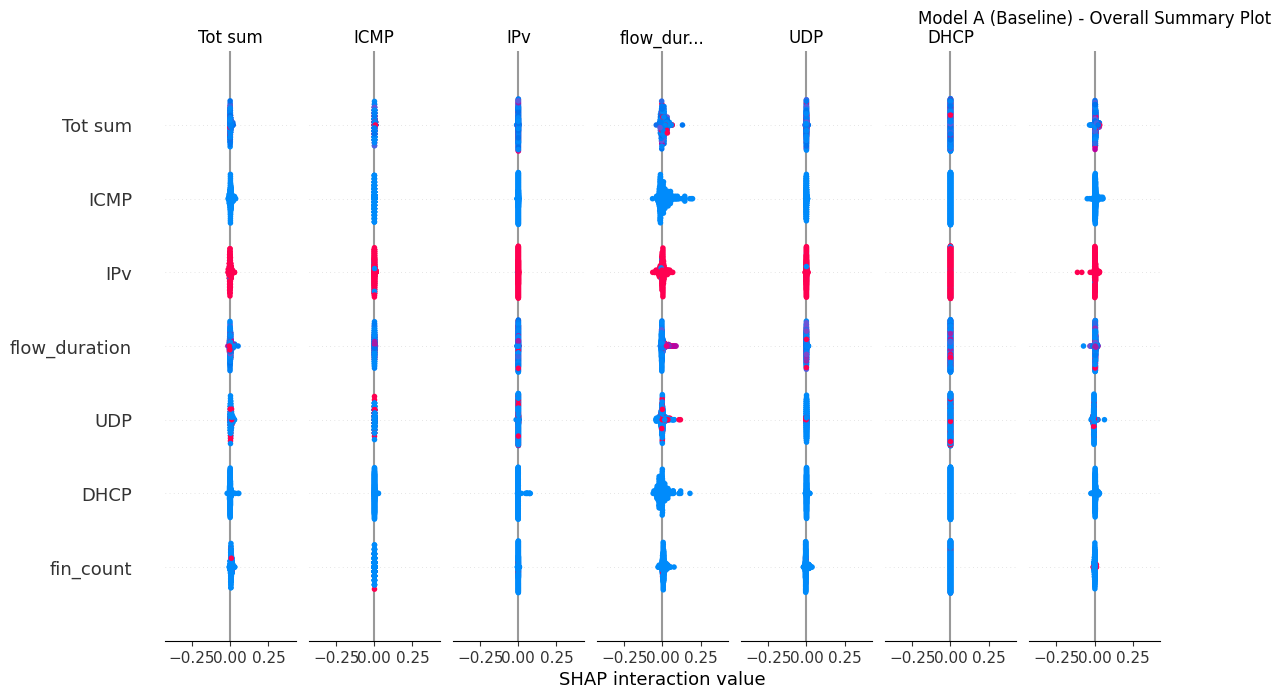

In [8]:
shap.summary_plot(shap_valuesA, X_sample_A, show=False)
plt.title('Model A (Baseline) - Overall Summary Plot', pad=20)
plt.show()

## 4. Class-Specific SHAP Summaries
Now let's isolate specific minority classes. GAN Augmentation (Model B) typically causes models to shift their reliance from generic artifact features to more class-specific informative features. Let's see how `SqlInjection` interpretations differ.\n

In [11]:
def plot_class_comparison(class_name):
    class_idx_A = list(leA.classes_).index(class_name)
    
    print(f"{'='*50}")
    print(f"   SHAP Summary for Class: {class_name}")
    print(f"{'='*50}")
    
    # Helper to handle older/newer shap structures
    sh_A = shap_valuesA[class_idx_A] if isinstance(shap_valuesA, list) else shap_valuesA[:, :, class_idx_A]    
    shap.summary_plot(sh_A, X_sample_A, show=False)
    plt.title(f'Model A (Baseline) - {class_name} (Index A: {class_idx_A})', pad=20)
    plt.show()

   SHAP Summary for Class: SqlInjection


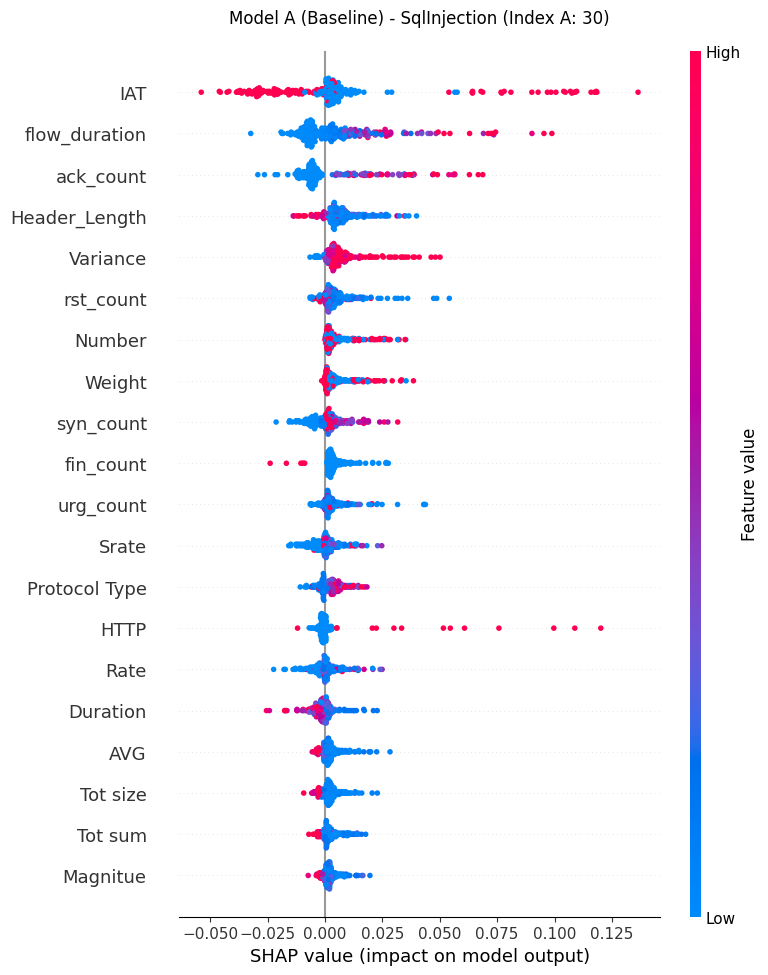

In [12]:
plot_class_comparison("SqlInjection")

   SHAP Summary for Class: Backdoor_Malware


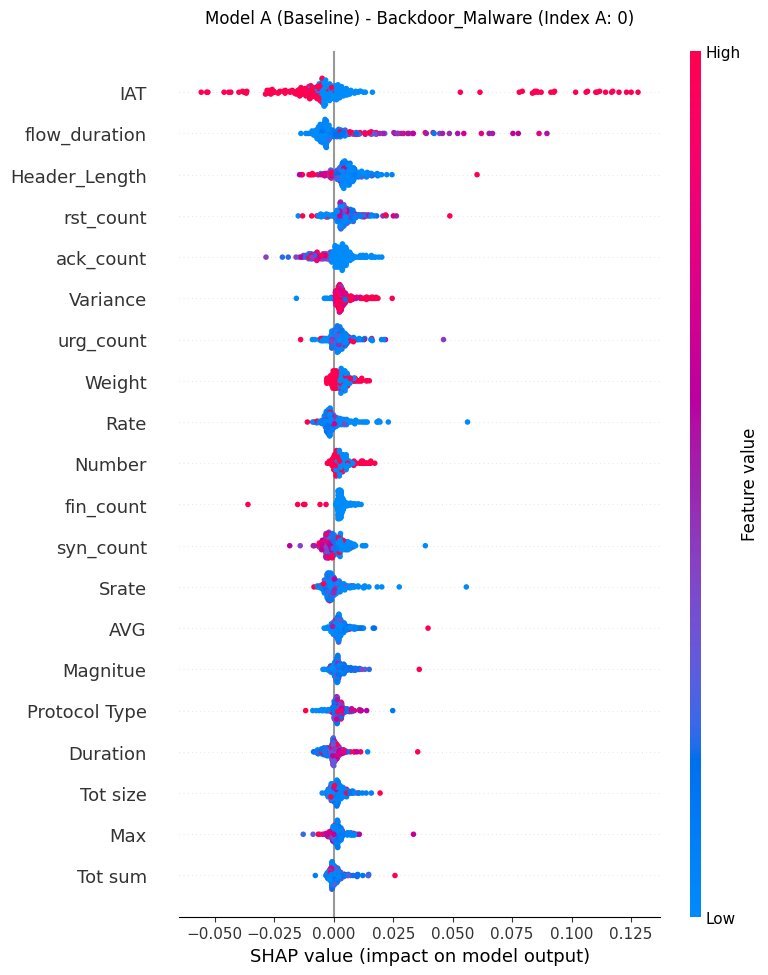

In [13]:
plot_class_comparison("Backdoor_Malware")

## 5. Feature Dependence Plots
Dependence plots show how a single feature impacts the output (SHAP value on the y-axis) across its entire range of values (x-axis), revealing non-linearities and interactions. (Using top feature of SqlInjection)\n

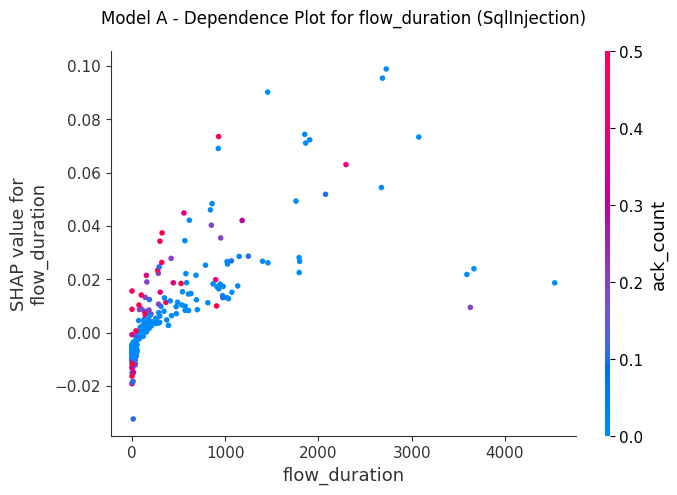

In [14]:
feature_to_plot = X_sample_A.columns[0] # You can change this to top feature observed above!
class_name = "SqlInjection"

class_idx_A = list(leA.classes_).index(class_name)

sh_A = shap_valuesA[class_idx_A] if isinstance(shap_valuesA, list) else shap_valuesA[:, :, class_idx_A]

shap.dependence_plot(feature_to_plot, sh_A, X_sample_A, show=False)
plt.title(f"Model A - Dependence Plot for {feature_to_plot} (SqlInjection)", pad=20)
plt.show()

## 6. Local Interpretability: Diving into a Single Prediction
What exactly makes the model predict `SqlInjection` on **one specific packet flow**? 
Waterfall plots explain a single prediction by starting at the `base_value` (average over the dataset) and adding/subtracting the SHAP values of each feature until we reach the final output value for that instance. 

- **Red bars**: Feature pushes the probability of this class UP.
- **Blue bars**: Feature pushes the probability DOWN.\n

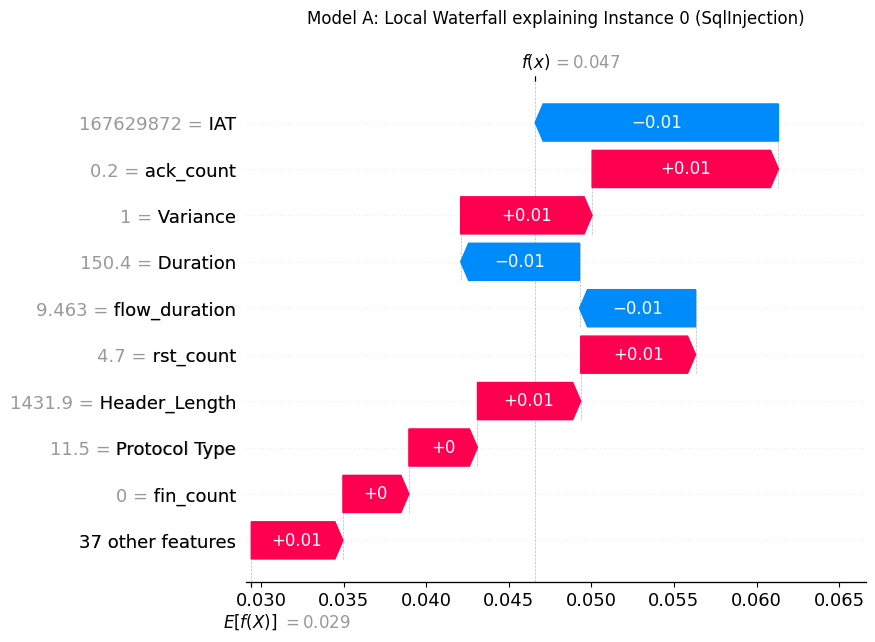

In [15]:
instance_idx = 0 # Selecting the first sample in our test subset
class_name = "SqlInjection"

class_idx_A = list(leA.classes_).index(class_name)

# Setup Explanation Object for A
expected_value_A = explainerA.expected_value[class_idx_A] if isinstance(explainerA.expected_value, (list, np.ndarray)) else explainerA.expected_value

expA = shap.Explanation(values=sh_A[instance_idx], 
                        base_values=expected_value_A, 
                        data=X_sample_A.iloc[instance_idx], 
                        feature_names=X_sample_A.columns)

# By default waterfall plots might not take nicely to external titles, 
# but calling it after plotting works best.
shap.waterfall_plot(expA, show=False)
plt.title("Model A: Local Waterfall explaining Instance 0 (SqlInjection)", pad=20)
plt.show()